In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from scipy.special import expit

# 固定随机种子，保证结果可复现 | Fix random seed for reproducibility
np.random.seed(42)

# ===================== 1. 生成模拟数据 =====================
def generate_one_site(n, p, p1, signal_strength):
    # 生成特征矩阵 | Generate feature matrix
    X = np.random.randn(n, p)
    # 生成真实系数（前p1个为真实特征） | Generate true coefficients (first p1 are true features)
    beta_true = np.zeros(p)
    beta_true[:p1] = signal_strength * np.random.choice([-1, 1], p1)
    # 生成二分类响应变量 | Generate binary response variable
    y = np.random.binomial(1, expit(X @ beta_true))
    return X, y, beta_true

# 模拟参数设置 | Simulation parameter settings
n = 100   # 单站点样本量 | Sample size per site
p = 10    # 总特征数 | Total number of features
p1 = 2    # 真实特征数 | Number of true features
signal_strength = 2.0  # 信号强度 | Signal strength

# 生成两个站点数据 | Generate data for two sites
site1_X, site1_y, beta_true1 = generate_one_site(n, p, p1, signal_strength)
site2_X, site2_y, beta_true2 = generate_one_site(n, p, p1, signal_strength)
print("=== 数据生成完成 ===") # === Data Generation Completed ===
print(f"特征数：{p}，真实特征：{set(range(p1))}") # Features: {p}, True Features: {set(range(p1))}

# ===================== 2. 本地DP特征粗筛 =====================
def local_dp_sis(X, y, mu1, d):
    n = X.shape[0]
    p = X.shape[1]
    
    # 计算边际相关性得分 | Calculate marginal correlation score
    r = X.T @ y / n
    # 计算全局敏感度 | Calculate global sensitivity
    delta_r = 2.0 / n
    # 加入GDP噪声 | Add GDP noise
    sigma_r = delta_r * 1.25 / mu1
    r_noisy = r + np.random.normal(0, sigma_r, p)
    # 选择前d个特征 | Select top d features
    top_indices = np.argsort(np.abs(r_noisy))[-d:]
    local_support = set(top_indices)
    
    return local_support, r_noisy

# 粗筛隐私预算与参数 | Screening privacy budget and parameters
mu1 = 0.5
d = 2 * p1

print("\n=== 站点1本地DP粗筛 ===") # === Site 1 Local DP Screening ===
site1_support, site1_r_noisy = local_dp_sis(site1_X, site1_y, mu1, d)
print(f"站点1支持集：{site1_support}") # Site 1 Support Set: {site1_support}

print("\n=== 站点2本地DP粗筛 ===") # === Site 2 Local DP Screening ===
site2_support, site2_r_noisy = local_dp_sis(site2_X, site2_y, mu1, d)
print(f"站点2支持集：{site2_support}") # Site 2 Support Set: {site2_support}

# ===================== 3. 多数表决生成鲁棒支持集 =====================
print("\n=== 多数表决 ===") # === Majority Voting ===
# 取交集作为鲁棒支持集 | Intersection as robust support set
S_robust = site1_support & site2_support
print(f"鲁棒支持集：{S_robust}") # Robust Support Set: {S_robust}

# ===================== 4. 私有化低维回归估计 =====================
def privatized_low_dim_estimation(X, y, features, mu2):
    n = X.shape[0]
    # 提取鲁棒特征子集 | Extract robust feature subset
    X_sub = X[:, list(features)]
    
    # 低维Ridge回归 | Low-dimensional Ridge regression
    ridge = Ridge(alpha=1e-5)
    ridge.fit(X_sub, y)
    beta_hat = ridge.coef_
    
    # 计算系数敏感度 | Calculate coefficient sensitivity
    cov_sub = X_sub.T @ X_sub / n
    min_eig = np.linalg.eigvalsh(cov_sub)[0]
    delta_beta = 2.0 / (n * min_eig)
    
    # 加入GDP噪声 | Add GDP noise
    sigma_beta = delta_beta * 1.25 / mu2
    beta_noisy = beta_hat + np.random.normal(0, sigma_beta, len(features))
    
    # 构造完整系数向量 | Construct full coefficient vector
    beta_full = np.zeros(p)
    beta_full[list(features)] = beta_noisy
    
    return beta_full

# 估计阶段隐私预算 | Estimation privacy budget
mu2 = 1.0

print("\n=== 站点1私有化估计 ===") # === Site 1 Privatized Estimation ===
site1_beta_noisy = privatized_low_dim_estimation(site1_X, site1_y, S_robust, mu2)

print("\n=== 站点2私有化估计 ===") # === Site 2 Privatized Estimation ===
site2_beta_noisy = privatized_low_dim_estimation(site2_X, site2_y, S_robust, mu2)

# 中心聚合私有化系数 | Center aggregates noisy coefficients
beta_noisy = np.array([site1_beta_noisy, site2_beta_noisy])

# ===================== 5. 中心计算广义镜像统计量 =====================
def compute_mirror_stats(beta_noisy):
    K = beta_noisy.shape[0]
    p = beta_noisy.shape[1]
    M = np.zeros(p)
    
    # 遍历所有站点对计算镜像统计量 | Iterate all site pairs to compute mirror stats
    for s in range(K):
        for t in range(s+1, K):
            beta_s = beta_noisy[s]
            beta_t = beta_noisy[t]
            sign = np.sign(beta_s * beta_t)
            abs_sum = np.abs(beta_s) + np.abs(beta_t)
            M += sign * abs_sum
    
    # 取平均值 | Take average
    M = M / (K*(K-1)/2)
    return M

# 计算镜像统计量 | Compute mirror statistics
M = compute_mirror_stats(beta_noisy)
print(f"\n广义镜像统计量：{M.round(3)}") # Generalized Mirror Statistics: {M.round(3)}

# 可视化镜像统计量 | Visualize mirror statistics
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10, 4))
plt.bar(range(p), M, color=['red' if i < p1 else 'blue' for i in range(p)])
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('特征索引') # Feature Index
plt.ylabel('镜像统计量M_j') # Mirror Statistics M_j
plt.title('镜像统计量分布（红色=真实特征）') # Distribution of Mirror Stats (Red=True Features)
plt.show()

# ===================== 6. FDR控制与结果评估 =====================
def fdr_control(M, alpha):
    # 所有阈值按绝对值降序排列 | All thresholds sorted by absolute value descending
    thresholds = np.sort(np.abs(M))[::-1]
    best_t = 0
    
    print("\n阈值搜索过程：") # Threshold Search Process:
    for t in thresholds:
        if t == 0:
            continue
        # 计算正负侧特征数 | Calculate number of positive/negative side features
        num_neg = np.sum(M < -t)
        num_pos = np.sum(M > t)
        # 估计FDP | Estimate FDP
        fdp_est = (num_neg + num_pos) / max(num_pos + num_neg, 1)
        print(f"  阈值t={t:.3f}，估计FDP={fdp_est:.3f}") # Threshold t={t:.3f}, Estimated FDP={fdp_est:.3f}
        if fdp_est <= alpha:
            best_t = t
            break
    
    # 选中显著特征 | Select significant features
    hat_S = set(np.where((M >= best_t) | (M <= -best_t))[0])
    return hat_S, best_t

# 目标FDR水平 | Target FDR level
alpha = 0.1

print("\n=== FDR控制 ===") # === FDR Control ===
hat_S, t_alpha = fdr_control(M, alpha)
print(f"最终阈值t_alpha={t_alpha:.3f}") # Final Threshold t_alpha={t_alpha:.3f}
print(f"选中特征集：{hat_S}") # Selected Feature Set: {hat_S}

# 计算评估指标 | Calculate evaluation metrics
S_true = set(range(p1))
TP = len(hat_S & S_true)
FP = len(hat_S - S_true)
FDR = FP / max(len(hat_S), 1)
Power = TP / len(S_true)

print("\n=== 最终评估结果 ===") # === Final Evaluation Results ===
print(f"真实特征集：{S_true}") # True Feature Set: {S_true}
print(f"选中特征集：{hat_S}") # Selected Feature Set: {hat_S}
print(f"真实FDR：{FDR:.3f}（目标：{alpha}）") # True FDR: {FDR:.3f} (Target: {alpha})
print(f"统计功效Power：{Power:.3f}") # Statistical Power: {Power:.3f}

NameError: name 'n' is not defined

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from scipy.special import expit

# 固定随机种子，保证结果可复现 | Fix random seed for reproducibility
np.random.seed(42)

In [3]:
# ===================== 1. 生成模拟数据 =====================
def generate_one_site(n, p, p1, signal_strength):
    # 生成特征矩阵 | Generate feature matrix
    X = np.random.randn(n, p)
    # 生成真实系数（前p1个为真实特征） | Generate true coefficients (first p1 are true features)
    beta_true = np.zeros(p)
    beta_true[:p1] = signal_strength * np.random.choice([-1, 1], p1)
    # 生成二分类响应变量 | Generate binary response variable
    y = np.random.binomial(1, expit(X @ beta_true))
    return X, y, beta_true

# 模拟参数设置 | Simulation parameter settings
n = 100   # 单站点样本量 | Sample size per site
p = 10    # 总特征数 | Total number of features
p1 = 2    # 真实特征数 | Number of true features
signal_strength = 2.0  # 信号强度 | Signal strength

# 生成两个站点数据 | Generate data for two sites
site1_X, site1_y, beta_true1 = generate_one_site(n, p, p1, signal_strength)
site2_X, site2_y, beta_true2 = generate_one_site(n, p, p1, signal_strength)
print("=== 数据生成完成 ===") # === Data Generation Completed ===
print(f"特征数：{p}，真实特征：{set(range(p1))}") # Features: {p}, True Features: {set(range(p1))}

=== 数据生成完成 ===
特征数：10，真实特征：{0, 1}


In [7]:
# ===================== 2. 本地DP特征粗筛 =====================
def local_dp_sis(X, y, mu1, d):
    n = X.shape[0]
    p = X.shape[1]
    
    # 计算边际相关性得分 | Calculate marginal correlation score
    r = X.T @ y / n
    # 计算全局敏感度 | Calculate global sensitivity
    delta_r = 2.0 / n
    # 加入GDP噪声 | Add GDP noise
    sigma_r = delta_r * 1.25 / mu1
    r_noisy = r + np.random.normal(0, sigma_r, p)
    # 选择前d个特征 | Select top d features
    top_indices = np.argsort(np.abs(r_noisy))[-d:]
    local_support = set(top_indices)
    
    return local_support, r_noisy

# 粗筛隐私预算与参数 | Screening privacy budget and parameters
mu1 = 0.5
d = 2 * p1

print("\n=== 站点1本地DP粗筛 === \n=== Site 1 Local DP Screening ===")
site1_support, site1_r_noisy = local_dp_sis(site1_X, site1_y, mu1, d)
print(f"站点1支持集：{site1_support}") # Site 1 Support Set: {site1_support}

print("\n=== 站点2本地DP粗筛 === \n === Site 2 Local DP Screening ===")
site2_support, site2_r_noisy = local_dp_sis(site2_X, site2_y, mu1, d)
print(f"站点2支持集：{site2_support}") # Site 2 Support Set: {site2_support}



=== 站点1本地DP粗筛 === 
=== Site 1 Local DP Screening ===
站点1支持集：{np.int64(0), np.int64(9), np.int64(2), np.int64(1)}

=== 站点2本地DP粗筛 === 
 === Site 2 Local DP Screening ===
站点2支持集：{np.int64(0), np.int64(1), np.int64(2), np.int64(7)}


In [11]:
# ===================== 3. 多数表决生成鲁棒支持集 =====================
print("\n=== 多数表决 === \n=== Majority Voting ===")
# 取交集作为鲁棒支持集 | Intersection as robust support set
S_robust = site1_support & site2_support
print(f"鲁棒支持集：{S_robust} \nRobust Support Set: {S_robust}")


=== 多数表决 === 
=== Majority Voting ===
鲁棒支持集：{np.int64(0), np.int64(1), np.int64(2)} 
Robust Support Set: {np.int64(0), np.int64(1), np.int64(2)}


In [12]:
# ===================== 4. 私有化低维回归估计 =====================
def privatized_low_dim_estimation(X, y, features, mu2):
    n = X.shape[0]
    # 提取鲁棒特征子集 | Extract robust feature subset
    X_sub = X[:, list(features)]
    
    # 低维Ridge回归 | Low-dimensional Ridge regression
    ridge = Ridge(alpha=1e-5)
    ridge.fit(X_sub, y)
    beta_hat = ridge.coef_
    
    # 计算系数敏感度 | Calculate coefficient sensitivity
    cov_sub = X_sub.T @ X_sub / n
    min_eig = np.linalg.eigvalsh(cov_sub)[0]
    delta_beta = 2.0 / (n * min_eig)
    
    # 加入GDP噪声 | Add GDP noise
    sigma_beta = delta_beta * 1.25 / mu2
    beta_noisy = beta_hat + np.random.normal(0, sigma_beta, len(features))
    
    # 构造完整系数向量 | Construct full coefficient vector
    beta_full = np.zeros(p)
    beta_full[list(features)] = beta_noisy
    
    return beta_full

# 估计阶段隐私预算 | Estimation privacy budget
mu2 = 1.0

print("\n=== 站点1私有化估计 ===\n=== Site 1 Privatized Estimation ===")
site1_beta_noisy = privatized_low_dim_estimation(site1_X, site1_y, S_robust, mu2)

print("\n=== 站点2私有化估计 ===\n=== Site 2 Privatized Estimation ===")
site2_beta_noisy = privatized_low_dim_estimation(site2_X, site2_y, S_robust, mu2)

# 中心聚合私有化系数 | Center aggregates noisy coefficients
beta_noisy = np.array([site1_beta_noisy, site2_beta_noisy])


=== 站点1私有化估计 ===
=== Site 1 Privatized Estimation ===

=== 站点2私有化估计 ===
=== Site 2 Privatized Estimation ===



广义镜像统计量：[-0.454  0.432  0.091  0.     0.     0.     0.     0.     0.     0.   ]
Generalized Mirror Statistics: [-0.454  0.432  0.091  0.     0.     0.     0.     0.     0.     0.   ]


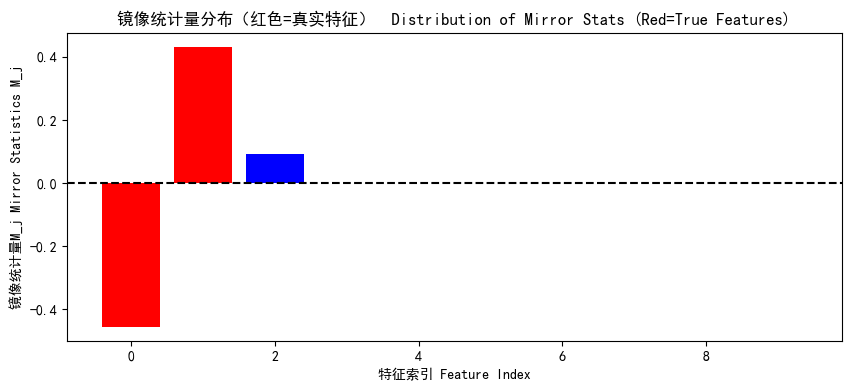

In [15]:
# ===================== 5. 中心计算广义镜像统计量 =====================
def compute_mirror_stats(beta_noisy):
    K = beta_noisy.shape[0]
    p = beta_noisy.shape[1]
    M = np.zeros(p)
    
    # 遍历所有站点对计算镜像统计量 | Iterate all site pairs to compute mirror stats
    for s in range(K):
        for t in range(s+1, K):
            beta_s = beta_noisy[s]
            beta_t = beta_noisy[t]
            sign = np.sign(beta_s * beta_t)
            abs_sum = np.abs(beta_s) + np.abs(beta_t)
            M += sign * abs_sum
    
    # 取平均值 | Take average
    M = M / (K*(K-1)/2)
    return M

# 计算镜像统计量 | Compute mirror statistics
M = compute_mirror_stats(beta_noisy)
print(f"\n广义镜像统计量：{M.round(3)}\nGeneralized Mirror Statistics: {M.round(3)}") 

# 可视化镜像统计量 | Visualize mirror statistics
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10, 4))
plt.bar(range(p), M, color=['red' if i < p1 else 'blue' for i in range(p)])
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('特征索引 Feature Index')
plt.ylabel('镜像统计量M_j Mirror Statistics M_j')
plt.title('镜像统计量分布（红色=真实特征）  Distribution of Mirror Stats (Red=True Features)')
plt.show()

In [17]:
# ===================== 6. FDR控制与结果评估 =====================
def fdr_control(M, alpha):
    # 所有阈值按绝对值降序排列 | All thresholds sorted by absolute value descending
    thresholds = np.sort(np.abs(M))[::-1]
    best_t = 0
    
    print("\n阈值搜索过程：\nThreshold Search Process:")
    for t in thresholds:
        if t == 0:
            continue
        # 计算正负侧特征数 | Calculate number of positive/negative side features
        num_neg = np.sum(M < -t)
        num_pos = np.sum(M > t)
        # 估计FDP | Estimate FDP
        fdp_est = (num_neg + num_pos) / max(num_pos + num_neg, 1)
        print(f"  阈值t={t:.3f}，估计FDP={fdp_est:.3f}\n Threshold t={t:.3f}, Estimated FDP={fdp_est:.3f}")
        if fdp_est <= alpha:
            best_t = t
            break
    
    # 选中显著特征 | Select significant features
    hat_S = set(np.where((M >= best_t) | (M <= -best_t))[0])
    return hat_S, best_t

# 目标FDR水平 | Target FDR level
alpha = 0.1

print("\n=== FDR控制 === \n === FDR Control ===")
hat_S, t_alpha = fdr_control(M, alpha)
print(f"最终阈值t_alpha={t_alpha:.3f}  Final Threshold t_alpha={t_alpha:.3f}")
print(f"选中特征集：{hat_S}  Selected Feature Set: {hat_S}")

# 计算评估指标 | Calculate evaluation metrics
S_true = set(range(p1))
TP = len(hat_S & S_true)
FP = len(hat_S - S_true)
FDR = FP / max(len(hat_S), 1)
Power = TP / len(S_true)

print("\n=== 最终评估结果 ===\n=== Final Evaluation Results ===")
print(f"真实特征集：{S_true}\nTrue Feature Set: {S_true}")
print(f"选中特征集：{hat_S}\n Selected Feature Set: {hat_S}")
print(f"真实FDR：{FDR:.3f}（目标：{alpha}）\n True FDR: {FDR:.3f} (Target: {alpha})")
print(f"统计功效Power：{Power:.3f}\nStatistical Power: {Power:.3f}")


=== FDR控制 === 
 === FDR Control ===

阈值搜索过程：
Threshold Search Process:
  阈值t=0.454，估计FDP=0.000
 Threshold t=0.454, Estimated FDP=0.000
最终阈值t_alpha=0.454  Final Threshold t_alpha=0.454
选中特征集：{np.int64(0)}  Selected Feature Set: {np.int64(0)}

=== 最终评估结果 ===
=== Final Evaluation Results ===
真实特征集：{0, 1}
True Feature Set: {0, 1}
选中特征集：{np.int64(0)}
 Selected Feature Set: {np.int64(0)}
真实FDR：0.000（目标：0.1）
 True FDR: 0.000 (Target: 0.1)
统计功效Power：0.500
Statistical Power: 0.500
